In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# -------------------------------
# 1. LOAD PREPROCESSED SCALED DATA
# -------------------------------
train_path = "../data/white_wine_train_scaled.csv"
test_path = "../data/white_wine_test_scaled.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("===== DATA LOADING =====")
print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

print("\nFirst 5 rows of training data:")
print(train_df.head())


===== DATA LOADING =====
Train dataset shape: (3168, 12)
Test dataset shape: (793, 12)

First 5 rows of training data:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       0.294664          1.649030    -0.774096       -0.652270  -0.261693   
1      -0.730467         -0.390108    -0.449229        1.298627   0.133466   
2      -0.274853          0.678011     0.119287        0.025410   0.748158   
3      -0.502660          0.969317    -1.180179       -0.282626  -0.349506   
4      -0.274853         -0.293007     0.200504        0.456661  -0.042160   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0            -0.636664             -1.173490 -1.766951 -1.689449  -0.974987   
1             1.103863             -0.092244  0.482598 -0.042890  -1.062307   
2            -0.230541              0.307346  0.540717 -0.635651  -0.189110   
3             0.059547             -0.421319 -0.778927 -0.833238  -0.625709   
4             1.1

In [2]:
# -------------------------------
# 2. SEPARATE FEATURES (X) AND TARGET (y)
# -------------------------------
X_train = train_df.drop(columns=["quality_label"])
y_train = train_df["quality_label"]

X_test = test_df.drop(columns=["quality_label"])
y_test = test_df["quality_label"]

print("\n===== FEATURES AND TARGET =====")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)



===== FEATURES AND TARGET =====
X_train shape: (3168, 11)
y_train shape: (3168,)
X_test shape: (793, 11)
y_test shape: (793,)


In [3]:
# -------------------------------
# 3. TRAIN KNN MODEL
# -------------------------------
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

print("\nKNN model trained successfully.")



KNN model trained successfully.


In [4]:
# -------------------------------
# 4. MAKE PREDICTIONS
# -------------------------------
y_pred = model.predict(X_test)

print("\nFirst 10 predictions:")
print(y_pred[:10])



First 10 predictions:
[1 1 1 1 1 1 1 1 1 1]


In [5]:
# -------------------------------
# 5. EVALUATE THE MODEL
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n===== KNN RESULTS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


===== KNN RESULTS =====
Accuracy  : 0.7264
Precision : 0.7762
Recall    : 0.8222
F1-Score  : 0.7985

Confusion Matrix:
[[146 124]
 [ 93 430]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.54      0.57       270
           1       0.78      0.82      0.80       523

    accuracy                           0.73       793
   macro avg       0.69      0.68      0.69       793
weighted avg       0.72      0.73      0.72       793



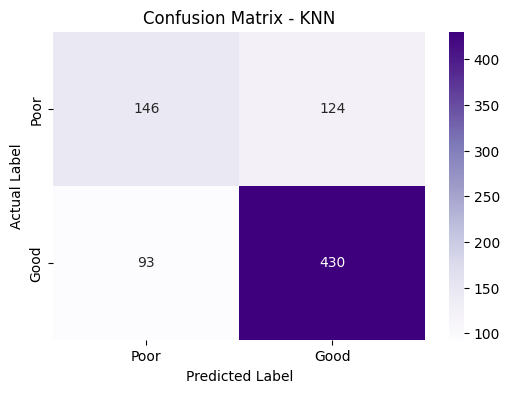

In [6]:
# -------------------------------
# 6. PLOT CONFUSION MATRIX
# -------------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Poor", "Good"],
    yticklabels=["Poor", "Good"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - KNN")
plt.show()